In [ ]:
# Importation des outils nécessaire
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import ipywidgets as widgets
from ipywidgets import interact, interact, fixed, interact_manual
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
from sklearn.feature_selection import RFE

In [ ]:
# Importer des données

df = pd.read_csv('/content/Telco-Customer-Churn.txt')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# Information sur l'ensemble des données
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# Nombre de valeurs uniques par colonne
df.nunique()

,0
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


## Analyse exploratoire des données

In [ ]:
from pandas.core.arrays import categorical
# Variables catégorielles
categorical_columns = df.nunique()[df.nunique() < 5].keys().to_list()
categorical_columns

['gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [ ]:
# Création d'une fonction de construction de graphiques à barres et de maniére intéractive

def bar_plot(a):
  df[a].value_counts(normalize=True).plot(kind='bar')
  plt.ylabel('Proportion')
  plt.title('Distribution of ' + str(a))
  return plt.show()

In [ ]:
# Interactive

interact(bar_plot, a=categorical_columns)

interactive(children=(Dropdown(description='a', options=('gender', 'SeniorCitizen', 'Partner', 'Dependents', '…

<function __main__.bar_plot(a)>

In [ ]:
# En séléctionnant Churn, on constate qu'il y'a plus de client qui ne sont pas désabonnés(plus de 70%)
# que de client qui se sont désabonné (moins de 30%).
# Donc nous avons un probléme de déséquilibre qu'il faudra absolument résoudre
# car cela peut impacter négativement la pérformance des modéles de classification que nous allons construire
# La distribution des données entre les différents sexes(gender) est à peu près également répartie
# Le nombre de clients (SeniorCitizen) qui sont des personnes âgés (moins de 20%) est bien inférieur à celui des clients jeunes (plus de 80%)
# La variable Partner indique si le client a un partenaire (Yes) ou pas (No). Les deux catégories ont pratiquement la même proportion



In [ ]:
# Echantillonnement aléatoire de la variable 'TotalCharge'
df['TotalCharges'].sample(10)

,TotalCharges
4097,6171.2
615,631.4
177,503.6
122,229.55
272,24.8
5318,2316.85
6608,1193.05
1594,1638.7
1489,1282.85
6082,6039.9


In [ ]:
# Variable quantitative
numerical_columns = df.nunique()[df.nunique() > 5].keys().to_list()
numerical_columns

['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [ ]:
numerical_columns = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Création d'une fonction de construction d'histogramme et de maniére interactive

def hist_plot(b):
  sns.displot(df[b], kde= False)
  plt.title(f'Histogramme de {str(b)}')
  return plt.show()

# Convertir du type des valeurs de la variable 'TotalCharges' en float (décimal)
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan).astype(float)

In [ ]:
# Interactive

interact(hist_plot, b=numerical_columns);

interactive(children=(Dropdown(description='b', options=('tenure', 'MonthlyCharges', 'TotalCharges'), value='t…

In [ ]:
# Coefficient d'asymetrie de la variable 'TotalCharges'

float(df['TotalCharges'].skew())

0.961642499724251

In [ ]:
# Création d'une fonction de construction de boites à moustaches et de maniére interactive

def box_plot(c):
  sns.boxplot(df[c])
  plt.title(f'Boite à moustaches de {str(c)}')
  return plt.show()

In [ ]:
# Interactive

interact(box_plot, c=numerical_columns);

interactive(children=(Dropdown(description='c', options=('tenure', 'MonthlyCharges', 'TotalCharges'), value='t…

/tmp/ipython-input-405641003.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


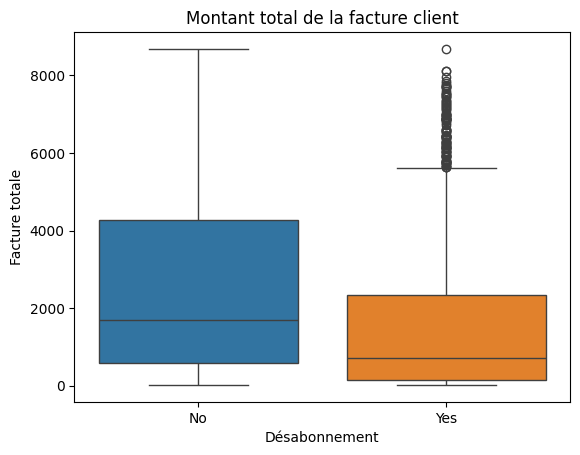

In [ ]:
# TotalCharge vs Churn

sns.boxplot(
    x='Churn',
    y='TotalCharges',
    data=df,
    palette='tab10'   # ou 'pastel', 'coolwarm', 'Set1','Set2','Set3','Pastel1','Pastel2','Dark2','Accent','Paired','Tab10','Tab20'
)

plt.ylabel('Facture totale')
plt.xlabel('Désabonnement')
plt.title('Montant total de la facture client')
plt.show()


/tmp/ipython-input-2394191809.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


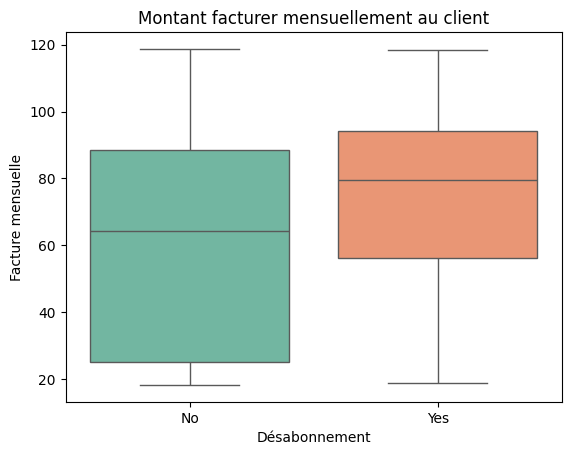

In [ ]:
# MonthlyCharges vs Churn


sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    data=df,
    palette='Set2'   # ou 'pastel', 'coolwarm', 'Set1','Set2','Set3','Pastel1','Pastel2','Dark2','Accent','Paired','Tab10','Tab20'
)

plt.ylabel('Facture mensuelle')
plt.xlabel('Désabonnement')
plt.title('Montant facturer mensuellement au client')
plt.show()


Le montant total facturé aux clients qui ont résilié leur contrat est inférieur au montant total facturé aux clients qui ne l'ont pas fais. Mais, les clients qui se sont désabonnés sont plus facturés mensuellement que les clients qui se sont pas désabonnés. Cette information est trés importante pour l'entreprise car le montant facturé mensuellement peut être un facteur important qui détermine si un client va se désabonner ou non.

/tmp/ipython-input-1300407343.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


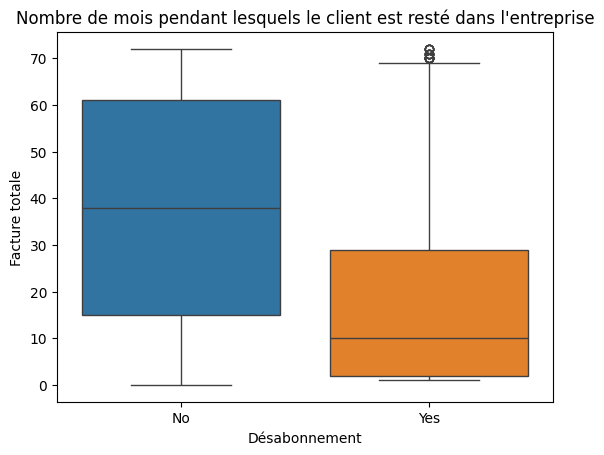

In [ ]:
# tenure vs Churn

sns.boxplot(
    x='Churn',
    y='tenure',
    data=df,
    palette='tab10'   # ou 'pastel', 'coolwarm', 'Set1','Set2','Set3','Pastel1','Pastel2','Dark2','Accent','Paired','Tab10','Tab20'
)

plt.ylabel('Facture totale')
plt.xlabel('Désabonnement')
plt.title("Nombre de mois pendant lesquels le client est resté dans l'entreprise")
plt.show()


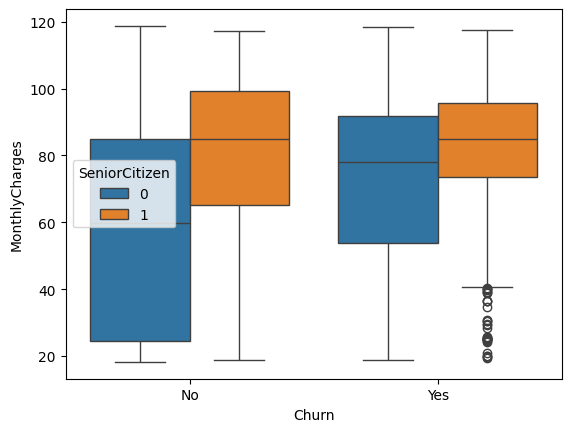

In [ ]:
# MonthlyCharges vs Churn by SeniorCitizen

sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    hue='SeniorCitizen',
    data=df,
    palette='tab10');

## Il semble que les personnes âgées soient beaucoup plus facturées que les jeunes. Malgrés cela ils restent plus fidéles à l'entreprise que les jeunes.

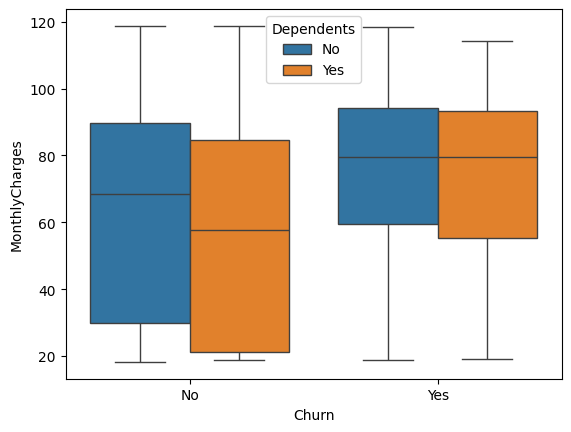

In [ ]:
# MonthlyCharges vs Churn by Dependents


sns.boxplot(
    x='Churn',
    y='MonthlyCharges',
    hue='Dependents',
    data=df,
    palette='tab10');

In [ ]:
# Résumé statistique
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


## Comme vous l'avez remarqué, les trois variables quantitatives (tenure, MonthlyCharges et TotalCharges) ont différentes échelles tenure varie entre 0 et 72 tandis que MonthlyCharges varie entre 18.25 et 118.75 et TotalCharges varie entre 18.8 et 8684.8. De nombreux modèles de Machine et de Deep Learning fonctinnent mieux avec des variables standardisées ou normalisées.

# On passe à la standardisarion des données dans la section de pretraitement des données

## Prétraitement des données

In [ ]:
# Gestion des valeurs manquants

data = df.copy()
data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Suppression des valeurs manquants

data.dropna(inplace=True)

In [ ]:
# Verification

data.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [ ]:
# Encodage des variables binaires
# En effet les algorithme de machine learning surtout ceux écrit dans la librairie scikit-learn ne prennent pas des valeurs chaines de caractére,
# elles ont bessoin uniquement les valeurs numérique

data['gender'] = data['gender'].apply(lambda x: 1 if x == 'Male' else 0)


In [ ]:

# Enumerer la liste des variables binaire à encoder le reste de mes variable
binary_columns = data.drop('gender', axis=1).nunique()[data.drop('gender', axis=1).nunique() < 3].keys().to_list()
binary_columns


['SeniorCitizen',
 'Partner',
 'Dependents',
 'PhoneService',
 'PaperlessBilling',
 'Churn']

In [ ]:
# Encoder ces variable binaire
for column in binary_columns:
  data[column] = data[column].apply(lambda x: 1 if x == 'Yes' else 0)

In [ ]:
# Encodage des variables catégorielles réstantes en excluant les variables binaires

remaining_cat_vars = data[categorical_columns].nunique()[data[categorical_columns].nunique() > 2].keys().to_list()
remaining_cat_vars_dummies = pd.get_dummies(data=data[remaining_cat_vars], columns=remaining_cat_vars, drop_first=True, dtype=int)

In [ ]:
# Nouvelle dataframe
data = pd.concat([data['gender'], data[binary_columns], remaining_cat_vars_dummies, data[numerical_columns]], axis=1)


In [ ]:
# Afficher la nouvelle data
data.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,Churn,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,0,0,1,0,0,1,0,1,0,0,...,0,0,0,0,0,1,0,1,29.85,29.85
1,1,0,0,0,1,0,0,0,0,0,...,0,0,1,0,0,0,1,34,56.95,1889.50
2,1,0,0,0,1,1,1,0,0,0,...,0,0,0,0,0,0,1,2,53.85,108.15
3,1,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,45,42.30,1840.75
4,0,0,0,0,1,1,1,0,0,1,...,0,0,0,0,0,1,0,2,70.70,151.65


In [ ]:
# La dimension
data.shape

(7032, 31)

In [ ]:
# Transformation de la variable 'TotalCharge'
# En effet plusieur algorithme de machine learning sont conçus pour fonctionner avec des variable normale ou pseudo normale ou à distribution symétrique
# Or la variable 'TotalCharge' est trés asymétrique car le coefficient d'asymétri est trés proche de 1 (0.96)
data['TotalCharges'] = np.sqrt(data['TotalCharges'])

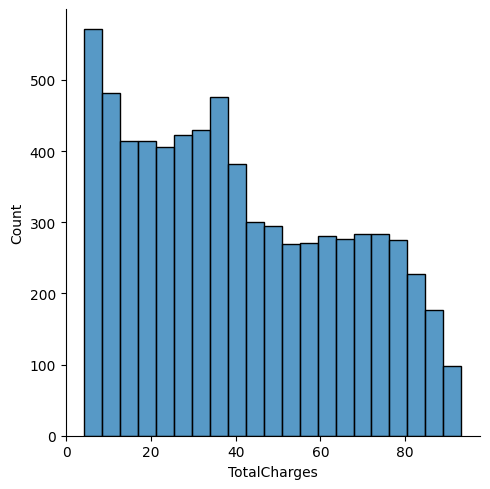

In [ ]:
# Histogramme de la variable transformée
sns.displot(data['TotalCharges'], kde=False)

In [ ]:
# Calculer à nouveau le coefficient d'asymétrie de la variable 'TotalCharges' après transformation
float(data['TotalCharges'].skew())

0.3089261418986736

In [ ]:
# Division des données en trois
# Données d'entrainement (60%), de validation (20%), et de test (20%)

x = data.drop('Churn', axis=1)
y = data['Churn']

seed = 111 # Pour s'assurer la reproductibilité des résultats

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.4, random_state=seed, stratify=y)
x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size=0.5, random_state=seed, stratify = y_test)

In [ ]:
# Fréquence des classes dans y

pd.DataFrame(y).value_counts(normalize = True)

,proportion
Churn,
0,0.734215
1,0.265785


In [ ]:
# Fréquence des classes dans y_train

pd.DataFrame(y_train).value_counts(normalize = True)

,proportion
Churn,
0,0.734297
1,0.265703


In [ ]:
# Fréquence des classes dans y_val

pd.DataFrame(y_val).value_counts(normalize = True)

,proportion
Churn,
0,0.733997
1,0.266003


In [ ]:
# Fréquence des classes dans y_test

pd.DataFrame(y_test).value_counts(normalize = True)

,proportion
Churn,
0,0.734186
1,0.265814


Attaquons-nous maintenant au problème de déséquilibre de classe dans les données.
Lorsqu'il y a une trés grande difference entre le nombre d'observations dans chaque catégories de la variable cuble à prédire, cela peut entrainer des érreurs de modélisations.

Dans notre cas ici, il y a un peu plus de 73% de personne qui n'ont pas résillié leur abonnenment contre environ un peu plus 26% qui ont résillié leur abonnement. Il y a donc un grand déséquilibre de classe. Nous pouvons utiliser le rééchantillonnage pour créer plus d'équilibre entre les catégories de la variable cible. Soit on crée plus d'observations dans la classe minoritaire (modalité 1) c'est-à-dire- on fait un sur-échantillonnage, soit on diminue les observations de la classe majoritaire (modalité 0) c'est-à-dire un sous-échantillonnage.

In [ ]:
# Résolution du problème de déséquilibre de classe : Méthode de sur-échantillonnage de la classe minoritaire

x2 = x_train
x2['Churn'] = y_train.values
minority = x2[x2.Churn == 1]
majority = x2[x2.Churn == 0]

minority_upsampled = resample(minority, replace=True, n_samples=len(majority), random_state=seed)
upsampled = pd.concat([majority, minority_upsampled])

upsampled

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges,Churn
2692,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,1,0,22,49.80,32.389041,0
664,0,0,1,1,1,0,0,0,0,1,...,0,0,1,0,0,0,57,19.50,34.170162,0
1027,0,0,0,0,1,0,0,1,1,0,...,0,1,0,1,0,0,47,94.90,67.935631,0
116,0,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,36,31.05,33.561138,0
4238,1,0,1,1,1,0,0,0,0,1,...,0,1,0,0,0,1,57,19.40,32.582204,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3248,1,0,1,0,1,1,0,1,1,0,...,1,0,0,0,1,0,10,86.65,29.268584,1
1772,1,0,0,0,1,0,0,0,1,0,...,0,0,0,0,1,0,2,79.00,11.985408,1
2124,1,0,1,0,0,1,1,0,0,0,...,0,0,0,0,1,0,5,24.95,10.019980,1
3384,0,0,1,1,1,1,0,0,1,0,...,0,0,0,0,1,0,4,73.75,18.040233,1


In [ ]:
# Vérification

upsampled['Churn'].value_counts(normalize = True)

,proportion
Churn,
0,0.5
1,0.5


In [ ]:
# Données d'entrainement sur la base la méthode de sur-échantillonnage de la classe minoritaire

x_train_up = upsampled.drop('Churn', axis=1)
y_train_up = upsampled['Churn']

In [ ]:
# Résolution du problème de déséquilibre de classe : Méthode de sous-échantillonnage de la classe majoritaire

majority_downsampled = resample(majority, replace=False, n_samples=len(minority), random_state=seed)
downsampled = pd.concat([minority, majority_downsampled])

downsampled

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges,Churn
1730,1,0,0,0,1,1,0,1,0,0,...,0,0,0,0,1,0,1,59.85,7.736278,1
3803,1,0,1,0,1,1,0,1,1,0,...,0,0,1,0,1,0,61,94.10,75.088614,1
5900,1,0,1,1,0,0,1,0,0,0,...,0,0,0,0,0,0,37,40.20,38.063105,1
3050,0,0,0,0,1,1,0,0,1,0,...,1,0,0,1,0,0,5,85.40,20.637345,1
2616,1,0,1,1,1,1,0,0,0,0,...,0,0,0,0,0,0,6,44.60,16.149303,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5096,1,0,1,1,1,0,0,1,0,0,...,1,0,1,0,0,0,71,86.85,79.144172,0
6627,0,0,1,0,1,0,0,0,0,1,...,0,1,0,0,0,1,59,20.35,35.594943,0
992,0,0,1,1,1,0,0,1,0,1,...,0,0,1,1,0,0,22,25.25,23.566926,0
363,0,0,0,0,1,1,0,0,0,1,...,0,0,1,0,0,1,47,20.55,30.752236,0


In [ ]:
# Vérification

downsampled['Churn'].value_counts(normalize = True)

,proportion
Churn,
1,0.5
0,0.5


In [ ]:
# Données d'entrainement sur la base la méthode de sous-échantillonnage de la classe majoritaire

x_train_down = downsampled.drop('Churn', axis=1)
y_train_down = downsampled['Churn']

In [ ]:
# y_train et x_train

y_train = x_train['Churn']

x_train = x_train.drop('Churn', axis=1)

In [ ]:
# Définition des données d'entrainement
# Choix possibles : (x_train_up, y_train_up) et (x_train_down, y_train_down)

train_feature = x_train_up
train_labels = y_train_up

## Passons finalement à la normalisation des données

In [ ]:
train_feature.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
2692,0,0,0,0,1,1,0,0,0,0,...,0,0,0,0,0,1,0,22,49.80,32.389041
664,0,0,1,1,1,0,0,0,0,1,...,1,0,0,1,0,0,0,57,19.50,34.170162
1027,0,0,0,0,1,0,0,1,1,0,...,0,0,1,0,1,0,0,47,94.90,67.935631
116,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,36,31.05,33.561138
4238,1,0,1,1,1,0,0,0,0,1,...,1,0,1,0,0,0,1,57,19.40,32.582204


In [ ]:
# Normalisation des variables indépendantes des différents ensembles de données puisqu'on
# a des variables qui ont de plus grandes valeus et d'autre ne le sont pas comme la variable 'tenure', 'MonthlyCharges', et 'TotalCharges'

scaler = MinMaxScaler()    # Standardisation : scaler = StandardScaler()
mod_scaler = scaler.fit(train_feature)
train_feature = mod_scaler.transform(train_feature)
x_val = mod_scaler.transform(x_val)
x_test = mod_scaler.transform(x_test)

# Retransformation en Dataframe

train_feature = pd.DataFrame(train_feature, columns = x.columns)
x_val = pd.DataFrame(x_val, columns = x.columns)
x_test = pd.DataFrame(x_test, columns = x.columns)



In [ ]:
# Toutes les valeurs sont maintenant entre 0 et 1

train_feature.head()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.295775,0.313373,0.315669
1,0.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.788732,0.010978,0.335715
2,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.647887,0.763473,0.715740
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.492958,0.126248,0.328861
4,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.788732,0.009980,0.317843


In [ ]:
# Résumé statistique

train_feature.describe()

,gender,SeniorCitizen,Partner,Dependents,PhoneService,PaperlessBilling,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,...,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,tenure,MonthlyCharges,TotalCharges
count,6196.000000,6196.0,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,...,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000,6196.000000
mean,0.489509,0.0,0.443673,0.258877,0.901711,0.648644,0.098289,0.437863,0.526146,0.163977,...,0.163977,0.403486,0.172853,0.172531,0.187218,0.417366,0.200452,0.380839,0.494373,0.381471
std,0.499930,0.0,0.496857,0.438053,0.297729,0.477432,0.297729,0.496164,0.499356,0.370284,...,0.370284,0.490636,0.378151,0.377872,0.390118,0.493164,0.400371,0.338999,0.287044,0.274408
min,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.056338,0.270334,0.138039
50%,0.000000,0.0,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.295775,0.561876,0.337908
75%,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.676056,0.720559,0.601192
max,1.000000,0.0,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


## Modélisation

In [ ]:
# Séléctionner des meilleures variables prédictives

rf = RandomForestClassifier()

rf.fit(train_feature, train_labels)

print(classification_report(y_val, rf.predict(x_val)))

              precision    recall  f1-score   support

           0       0.83      0.87      0.85      1032
           1       0.57      0.50      0.54       374

    accuracy                           0.77      1406
   macro avg       0.70      0.68      0.69      1406
weighted avg       0.76      0.77      0.76      1406



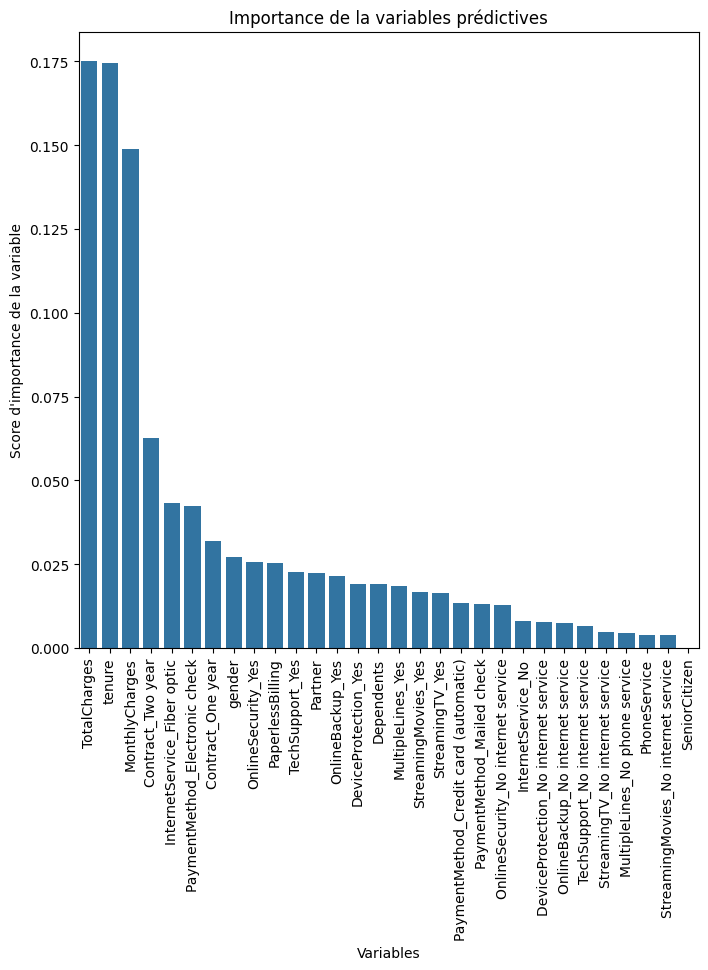

In [ ]:
# Importer des variables importantes

vars_imp = pd.Series(rf.feature_importances_, index=train_feature.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 8))
sns.barplot(x=vars_imp.index, y=vars_imp)
plt.xticks(rotation=90)
plt.xlabel("Variables")
plt.ylabel("Score d'importance de la variable")
plt.title("Importance de la variables prédictives")
plt.show()

In [ ]:
# Affichage de vars_impo

vars_imp

,0
TotalCharges,0.175026
tenure,0.174456
MonthlyCharges,0.148782
Contract_Two year,0.062566
InternetService_Fiber optic,0.043399
PaymentMethod_Electronic check,0.042491
Contract_One year,0.031830
gender,0.027264
OnlineSecurity_Yes,0.025539
PaperlessBilling,0.025472


In [ ]:
# Variables séléctionnées pour les algorithmes

seuil = 0.004
vars_selected = vars_imp[vars_imp > seuil].index.to_list()

train_feature = train_feature[vars_selected]
x_val = x_val[vars_selected]
x_test = x_test[vars_selected]

In [ ]:
# Nombre de variables prédictives

len(vars_selected)

28

In [ ]:
len(train_feature.columns)

28

##<font color="red"><b>Modèle de Regression logistique</b></font>

In [ ]:
from ast import Param
# Dictionnaire des hyperparamètres

param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 50, 100, 500]}

# Objet GridSearchCV

grid_logreg_class = GridSearchCV(estimator=LogisticRegression(random_state=seed,max_iter=500),param_grid=param_grid, scoring='f1', cv=5)

# Entrainement de l'algorithme

logreg_model = grid_logreg_class.fit(train_feature, train_labels)

# Meilleursscore et meilleur hyperparamètres

print(logreg_model.best_score_, 3)

print(logreg_model.best_estimator_)

0.7740556694314611 3
LogisticRegression(C=10, max_iter=500, random_state=111)


## Le modèle a un bon score d'entrainement. Evaluons sa performance sur les données de validation afin d'apprécier sa capacité à générer sur de nouvelles données.

In [ ]:
# Fonction d'évaluation de la performance

def model_evaluation(model, features, labels):
  pred = model.predict(features)
  print(classification_report(labels, pred))

In [ ]:
# Evaluation du modèle de régression logistique

model_evaluation(logreg_model, x_val, y_val)

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1032
           1       0.53      0.75      0.62       374

    accuracy                           0.75      1406
   macro avg       0.71      0.75      0.72      1406
weighted avg       0.80      0.75      0.77      1406



## Appliquons l'algorithme Recurcive Feature Eliminator (RFE) sur le modèle afin de voir s'il garde les mêmes performances lorqu'on réduit le nombre de prédicteurs. En effet, plus le modèle est complexe, plus il est dificile de l'interpreter.

##<font color="red"><b>Fonction de construction d'un modèle avec utilisation de l'algorithme RFE</b></font>

In [ ]:
# Création d'une fonction de construction d'un modèle avec utilisation de l'algorithme RFE

def model_with_rfe(model):
  rfe_model = RFE(estimator=model, verbose=0)
  rfe_model.fit(train_feature, train_labels)
  mask = rfe_model.support_
  reduced_x = train_feature.loc[:, mask]
  print(reduced_x.columns)
  return rfe_model

In [ ]:
# Logistic Regression RFE

rfe_logreg_model = model_with_rfe(logreg_model.best_estimator_)

rfe_logreg_model

Index(['TotalCharges', 'MonthlyCharges', 'Contract_Two year',
       'InternetService_Fiber optic', 'PaymentMethod_Electronic check',
       'Contract_One year', 'PaperlessBilling', 'MultipleLines_Yes',
       'StreamingMovies_Yes', 'StreamingTV_Yes',
       'OnlineSecurity_No internet service',
       'DeviceProtection_No internet service',
       'OnlineBackup_No internet service', 'TechSupport_No internet service'],
      dtype='object')


RFE(estimator=LogisticRegression(C=10, max_iter=500, random_state=111))

In [ ]:
# Evaluation du model de régression logistique avec RFE

model_evaluation(rfe_logreg_model, x_val, y_val)

              precision    recall  f1-score   support

           0       0.89      0.75      0.82      1032
           1       0.52      0.75      0.62       374

    accuracy                           0.75      1406
   macro avg       0.71      0.75      0.72      1406
weighted avg       0.79      0.75      0.76      1406



# Le RFE a réduit le nombre de prédictive de 28 à 14 et n'a pas améliorer la performance du modèle. Cela montre non seulement la puissance de cet algorithme mais aussi l'importance de la séléction des meilleurs prédictives en modélisation.

##<font color="red"><b>Modèle de Forêt Aléatoire</b></font>

In [ ]:
# Dictionnaire des hypérparametres

param_grid_rf = {'n_estimators': [10, 50, 100, 1000],
              'max_depth': [3, 5, 10, 20, None]}

# Objet GridSearchCV

grid_rf_class = GridSearchCV(estimator=RandomForestClassifier(random_state=seed),
                                 param_grid=param_grid_rf,
                                 scoring='f1',
                                 cv=5)

# Entrainement de l'algorithme

rf_model = grid_rf_class.fit(train_feature, train_labels)

# Meilleur score et meilleur hyperparamètres

print(round(rf_model.best_score_, 3))

print(rf_model.best_estimator_)

0.914
RandomForestClassifier(max_depth=20, n_estimators=50, random_state=111)


In [ ]:
# Evalution du modèle de forêt aléatoire

model_evaluation(rf_model.best_estimator_, x_val, y_val)

              precision    recall  f1-score   support

           0       0.83      0.86      0.84      1032
           1       0.56      0.50      0.53       374

    accuracy                           0.76      1406
   macro avg       0.70      0.68      0.69      1406
weighted avg       0.76      0.76      0.76      1406



## Comparé aux valeurs du modèle de régression logistique, le modèle de forêt aléatoire semble moins efficace.

##<font color="red"><b>Appliquons une RFE</b></font>

In [ ]:
# Random Forest avec RFE

rfe_forest_model = model_with_rfe(rf_model.best_estimator_)

rfe_forest_model

Index(['TotalCharges', 'tenure', 'MonthlyCharges', 'Contract_Two year',
       'InternetService_Fiber optic', 'PaymentMethod_Electronic check',
       'Contract_One year', 'gender', 'OnlineSecurity_Yes', 'PaperlessBilling',
       'TechSupport_Yes', 'Partner', 'OnlineBackup_Yes', 'Dependents'],
      dtype='object')


RFE(estimator=RandomForestClassifier(max_depth=20, n_estimators=50,
                                     random_state=111))

In [ ]:
# Evaluation du modèle de forêt aléatoire avec RFE

model_evaluation(rfe_forest_model, x_val, y_val)

## Au vu de ces valeurs, nous retiendrons le modèle de forêt aléatoire abtenu sans RFE.

## Voyons maintenant à la construction d'un modèle de réseau de neuronnes artificiel.

##<font color="red"><b>Classification Perception multicouche</b></font>


In [ ]:
# MLPClassifier

mlp = MLPClassifier(random_state=seed, max_iter=1000)

parameters = {'hidden_layer_sizes' :[(50,), (100,), (200,)],
              #'activation' :['identity', 'logistic', 'tanh', 'relu'],
              'learning_rate' :['constant', 'invscaling', 'adaptive']}

mlp_cv = GridSearchCV(mlp, parameters, scoring='f1', cv=5, n_jobs=1)

# Entrainer l'algorithme

mlp_cv.fit(train_feature, train_labels)

In [ ]:
# Meilleur score et meilleur hyperparamètre

float(round(mlp_cv.best_score_, 3))

In [ ]:
mlp_cv.best_estimator_

In [ ]:
# Evaluation du modèle perception

model_evaluation(mlp_cv.best_estimator_, x_val, y_val)

## Passons maintenant à un modèle SVM (Support Vector Machine)

##<font color="red"><b>Support Vector Machine</b></font>


In [ ]:
# Support Vector Machine : Classifier qui trouve l'hyperplan optimal qui maximise la frontière entre 2 classes

svm_model = SVC(random_state=seed)

svm_hyp = {'kernel' :['linear', 'rbf'], 'C' :[0.1, 1.0, 10, 50, 100]}

svm_cv = GridSearchCV(svm_model, svm_hyp, scoring='f1', cv=5)

# Entrainer l'algorithme

svm_cv.fit(train_feature, train_labels)

# Meilleur score et meilleur hyperparametre

print(round(svm_cv.best_score_, 3))

print(svm_cv.best_estimator_)

In [ ]:
# Evaluation du modèle SVM

model_evaluation(svm_cv.best_estimator_, x_val, y_val)

##<font color="green"><b>Conclusion :</b> </font>


## J'ai utilisés les données d'évaluation pour sélectionner le meilleur modèle. Ensuite nous évaluons le meilleur modèle sélectionné sur les données de test afin d'apprécier sa performance sur de nouvelle données. Idéalement les performances de ce modèle sur les données d'évaluation et sur les données de test doivent être relativement proches.

In [ ]:
# Sur les donnés de validation
model_evaluation(logreg_model.best_estimator_, x_val, y_val)

In [ ]:
# Performance du meilleur modèle sur les données de test

model_evaluation(logreg_model.best_estimator_, x_test, y_test)